# Qwen2-VL-2B Model Evaluation

This notebook evaluates the performance of Qwen-VL-2.5B model on our fire detection dataset.

In [1]:
# For virtual environment only, ignore this cell if you're using personal computer
!source ../../miniconda3/bin/activate
!conda --version

conda 24.11.3


In [2]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, Qwen2_5_VLProcessor, AutoTokenizer, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
from qwen_vl_utils import process_vision_info
import matplotlib.pyplot as plt
import time
import re, json

In [3]:
# Load ground truth data
df = pd.read_csv('../test_labels.csv')
print(f"Total samples in dataset: {len(df)}")
df.head()

Total samples in dataset: 1290


,image_path,label,caption
0,fine_tune_dataset/test/images/test_1.jpg,dangerous fire,The image shows a close-up view of an electric...
1,fine_tune_dataset/test/images/test_2.jpg,controlled fire,"The image shows a narrow, dark tunnel with a b..."
2,fine_tune_dataset/test/images/test_3.jpg,controlled fire,The image shows a nighttime camping scene with...
3,fine_tune_dataset/test/images/test_4.jpg,controlled fire,A piece of paper is being burned on a white pl...
4,fine_tune_dataset/test/images/test_5.jpg,no fire,The image shows a small room with a white wall...


In [ ]:
# Initialize model and processor
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_use_double_quant=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.bfloat16
)

processor = Qwen2_5_VLForConditionalGeneration.from_pretrained(model_name)
model = Qwen2_5_VLProcessor.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
    trust_remote_code=True,
    quantization_config = bnb_config
)

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def process_image(image_path):
    """Process a single image and return the model's prediction, caption and inference time"""
    try:
        # Start timing
        start_time = time.time()
        
        # Load image
        image = Image.open(image_path).convert("RGB")
        
        # Fire analysis prompt
        system_prompt = (
            "You are a visual analyst evaluating an image for signs of fire and the surrounding context. "
            "Do the following tasks:\n"
            "1: Summarize what you see in the image. Describe the environment, key objects, people, and any signs of fire or smoke.\n"
            "2: Based on your summary, classify the fire situation: "
            "no fire(e.g., fire alarm, fire distinguisher, laptop displaying fire, painting or drawing of fire..), controlled fire (e.g., active fireplace, campfire, cooking, candles, match stick, lighter..) or a dangerous/uncontrolled fire (e.g., curtains on fire, smoke on ceiling, couch on fire, bed sheet on fire, spreading fire towards flammable furniture..)\n"
            "Return only this JSON format:\n"
            "{ \"caption\": \"...\", \"label\": \"no fire\"|\"controlled fire\"|\"dangerous fire\" }"
        )

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": system_prompt}
            ]
        }]

        # Generate prompt and inputs
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages) #this is for qwen family only, for other models please remove
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        ).to(device)

        # Generate response
        with torch.no_grad():
            generate_ids = model.generate(
                **inputs,
                max_new_tokens=1024,
                do_sample=True,
                top_k=50,
                top_p=0.95,
                num_return_sequences=1,
            )
        
        output = processor.tokenizer.batch_decode(generate_ids, skip_special_tokens=True)[0]
        if output.startswith("system"):
            output = output.split("assistant", 1)[-1].strip()

        clean_output = re.sub(r'^(system|user|assistant)\n', '', output, flags=re.MULTILINE).strip()

        # Match the last complete JSON block
        matches = re.findall(r'\{[^{}]+\}', clean_output, re.DOTALL)
        if matches:
            try:
                result = json.loads(matches[-1])  # take the last match (most likely correct)
                caption = result.get("caption", "").strip()
                label = result.get("label", "").strip()
            except Exception as e:
                print(f"❌ Failed to parse JSON for {image_path}: {e}")
                caption = clean_output
                label = "unknown"
        else:
            print(f"❌ No JSON block found in output for {image_path}")
            caption = clean_output
            label = "unknown"

        # Calculate inference time
        inference_time = time.time() - start_time
        
        return label, caption, inference_time
            
    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return "error", "", 0.0

In [ ]:
# Process all images and collect predictions
predictions = []
captions = []
inference_times = []
ground_truth = []

for idx, row in df.iterrows():
    img_path = os.path.join('../', row['image_path'])
    if os.path.exists(img_path):
        pred, caption, inf_time = process_image(img_path)
        predictions.append(pred)
        captions.append(caption)
        inference_times.append(inf_time)
        ground_truth.append(row['label'])
        if idx % 10 == 0:
            print(f"Processed {idx} images... Average inference time so far: {np.mean(inference_times):.3f}s")

print(f"\nProcessing complete! Average inference time: {np.mean(inference_times):.3f}s")

Processed 0 images... Average inference time so far: 7.030s
Processed 10 images... Average inference time so far: 6.803s


KeyboardInterrupt: 

In [ ]:
# Save results to CSV
results_df = pd.DataFrame({
    'image_path': df['image_path'],
    'true_label': ground_truth,
    'predicted_label': predictions,
    'caption': captions,
    'inference_time': inference_times,
    'correct': [t == p for t, p in zip(ground_truth, predictions)]
})

results_df.to_csv('qwen2.5_vl_3B_results.csv', index=False)
print("Results saved to qwen2.5_vl_3B_base_results.csv")

Results saved to qwen2.5_vl_3B_base_results.csv


In [ ]:
# Load the CSV file
df = pd.read_csv("qwen2_vl_2B_results.csv")
df = df.dropna(subset=['true_label', 'predicted_label', 'inference_time'])  # Remove rows with missing values

# Extract relevant columns
ground_truth = df['true_label'].astype(str).str.strip()
predictions = df['predicted_label'].astype(str).str.strip()
inference_times = df['inference_time'].astype(float)

# Calculate classification metrics
accuracy = accuracy_score(ground_truth, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(
    ground_truth, predictions, average='weighted'
)

# Print performance metrics
print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Inference time stats
print("\nInference Time Statistics:")
print(f"Average: {np.mean(inference_times):.3f}s")
print(f"Std Dev: {np.std(inference_times):.3f}s")
print(f"Min: {np.min(inference_times):.3f}s")
print(f"Max: {np.max(inference_times):.3f}s")

Model Performance Metrics:
Accuracy: 0.8769
Precision: 0.9272
Recall: 0.8769
F1 Score: 0.8921

Inference Time Statistics:
Average: 2.021s
Std Dev: 1.331s
Min: 1.273s
Max: 23.814s


/home/student4/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


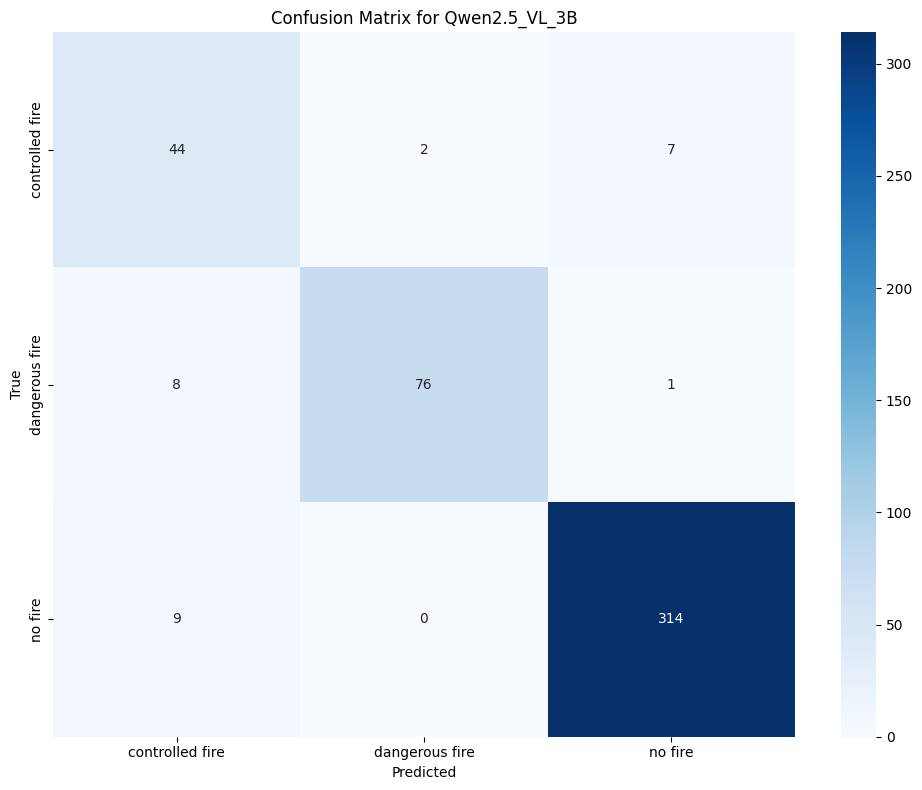

In [ ]:
# Confusion matrix
labels = sorted(df['true_label'].unique())
cm = confusion_matrix(ground_truth, predictions, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix for Qwen2.5_VL_3B')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()